## Data cleaning

I first clean the dataset from Xie et al. (2025) to isolate the anti-diabetic peptides (ADPs), which I use as my positive class, because I construct my own negative (non-ADP) class. To avoid class imbalance I build a dual-negative class equal in number to the ADPs: soft negatives (antimicrobial peptides from DBAASP, controlling for generic bioactivity) and hard negatives (length-matched random fragments from reviewed Swiss-Prot proteins via the UniProt API, excluding proteins annotated for glucose homeostasis or insulin signalling to prevent contamination).

**Paper:** Xie, X. et al. (2025). BertADP: a fine-tuned protein language model for anti-diabetic peptide prediction. BMC Biology, 23 (1), p.210. [Online]. Available at: doi:10.1186/s12915-025-02312-w [Accessed 5 March 2026].



In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
raw_adp_df = pd.read_csv("data/allData.csv")
raw_adp_df.head()

,Sequence,Label,Length,Source
0,AP,1,2,test
1,LP,1,2,test
2,IP,1,2,test
3,MFE,1,3,test
4,STY,1,3,test


According to the paper, the label represents weather the protein is ADP or non-ADP. 966 positives (antidiabetic, label=1) and 966 negatives (non-antidiabetic, label=0). Theyve done their own Train/Test split so i can remove this column and just isolate my own dataset of ADPs for now.

In [3]:
raw_adp_df = raw_adp_df.drop(columns=["Source"], axis=1) # drop the train/test split column
raw_adp_df = raw_adp_df[(raw_adp_df["Label"] == 1)].copy() # 1 represents ADPs. Made a copy so the original df is not modified.
raw_adp_df.head()

,Sequence,Label,Length
0,AP,1,2
1,LP,1,2
2,IP,1,2
3,MFE,1,3
4,STY,1,3


In [4]:
# There should be 966 ADPs in the dataset
print(f"There are {raw_adp_df.shape[0]} ADPs in the dataset.") # index 0 shows number of rows

There are 966 ADPs in the dataset.


Ill save just the positives to be used in part 1.2

In [5]:
raw_adp_df.to_csv("data/positives_ADP.csv", index=False)

Im interested in the distribution of sequence lengths in my ADP dataset. This would be good in order to see distribution.

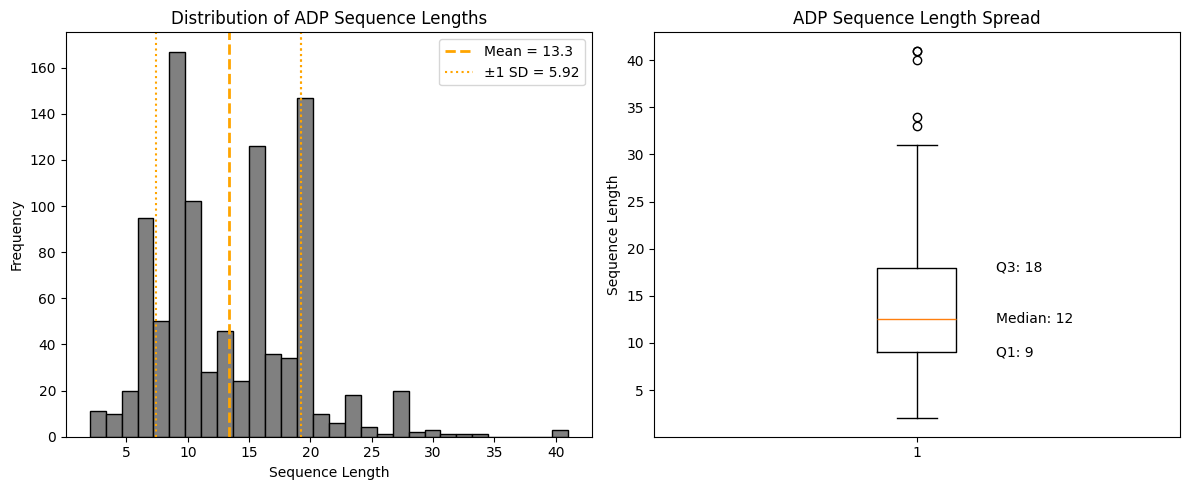

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Calculate stats
len_mean = np.mean(raw_adp_df["Length"])
len_std = np.std(raw_adp_df["Length"])
median = np.median(raw_adp_df['Length'])
q1 = np.percentile(raw_adp_df['Length'], 25)
q3 = np.percentile(raw_adp_df['Length'], 75)

# Histogram of sequence lengths
ax[0].hist(raw_adp_df['Length'], bins=30, color='grey', edgecolor='black') 
ax[0].set_xlabel('Sequence Length')
ax[0].set_ylabel('Frequency')
ax[0].set_title('Distribution of ADP Sequence Lengths')
ax[0].axvline(len_mean, color="orange", linestyle="dashed", linewidth=2,
            label=f"Mean = {len_mean:.1f}")
ax[0].axvline(len_mean - len_std, color="orange", linestyle="dotted", linewidth=1.5,
            label=f"±1 SD = {len_std:.2f}")
ax[0].axvline(len_mean + len_std, color="orange", linestyle="dotted", linewidth=1.5)
ax[0].axvline(len_mean + len_std, color="orange", linestyle="dotted", linewidth=1.5)
ax[0].legend(loc="upper right")

# Box plot of sequence lengths
ax[1].boxplot(raw_adp_df['Length'], vert=True)
ax[1].set_ylabel('Sequence Length')
ax[1].set_title('ADP Sequence Length Spread')
ax[1].text(1.15, median, f'Median: {median:.0f}', va='center')
ax[1].text(1.15, q1, f'Q1: {q1:.0f}', va='center')
ax[1].text(1.15, q3, f'Q3: {q3:.0f}', va='center')

plt.tight_layout()
plt.show()

Histogram (left)
- Bimodal (peaks  and 19) → two sub-groups, shorter and longer ADPs.
- Most fall in 5–25 residues; right-skewed with a tail to ~40.
- Mean 13.3, SD 5.92.

Box plot (right)
- Median ~12; IQR 9–18 (middle 50% of ADPs).
- Whiskers 2–32, with a few outliers at 33–40 (unusually long ADPs).